# CNN Model (TensorFlow) for Respiratory Disease Classification

Train a CNN on cycle-level spectrograms and evaluate at patient level with probability aggregation.

In [1]:
from pathlib import Path
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix, f1_score

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

print('TensorFlow version:', tf.__version__)

TensorFlow version: 2.21.0


## 1) Load Metadata and Verify Spectrogram Paths
Load processed_audio/metadata.csv, verify required columns and spectrogram paths, and split by `split`.

In [2]:
cwd = Path.cwd().resolve()
project_root = cwd if (cwd / 'processed_audio').exists() else cwd.parent
metadata_path = project_root / 'processed_audio' / 'metadata.csv'

if not metadata_path.exists():
    raise FileNotFoundError(f'Metadata file not found: {metadata_path}')

df = pd.read_csv(metadata_path)
required_cols = ['patient_id', 'spectrogram_path', 'diagnosis', 'split']
missing_cols = [c for c in required_cols if c not in df.columns]
if missing_cols:
    raise ValueError(f'Missing required columns: {missing_cols}')

df = df.copy()
df['diagnosis'] = df['diagnosis'].astype(str).str.strip()
df['split'] = df['split'].astype(str)
df['spectrogram_path'] = df['spectrogram_path'].astype(str)
df = df[df['diagnosis'] != '']

df['spec_path_abs'] = df['spectrogram_path'].map(lambda p: project_root / str(p))
missing_paths = df[~df['spec_path_abs'].map(lambda p: p.exists())]
if not missing_paths.empty:
    raise FileNotFoundError(
        f"Missing spectrogram files. Examples: {missing_paths['spectrogram_path'].head(5).tolist()}"
    )

splits = ['train', 'validation', 'test']
df_splits = {s: df[df['split'] == s].copy() for s in splits}
for s in splits:
    if df_splits[s].empty:
        raise ValueError(f'No samples found for split: {s}')

split_counts = df[['patient_id', 'split']].drop_duplicates().groupby('patient_id')['split'].nunique()
leaky_patients = split_counts[split_counts > 1]
print('Patients appearing in multiple splits:', len(leaky_patients))
if len(leaky_patients) > 0:
    display(leaky_patients.head(10))

print('Train/Val/Test sizes:', {k: len(v) for k, v in df_splits.items()})

Patients appearing in multiple splits: 0
Train/Val/Test sizes: {'train': 4503, 'validation': 1288, 'test': 1107}


## 2) Encode Diagnosis Labels and Save Mapping
Fit a label encoder and store the label ↔ index mapping.

In [3]:
label_encoder = LabelEncoder()
df['label'] = label_encoder.fit_transform(df['diagnosis'])
label_mapping = {label: int(idx) for idx, label in enumerate(label_encoder.classes_)}
inv_label_mapping = {int(idx): label for label, idx in label_mapping.items()}
df_splits = {s: df[df['split'] == s].copy() for s in splits}
display(pd.DataFrame({'label': list(label_mapping.keys()), 'index': list(label_mapping.values())}))

,label,index
0,Bronchiectasis,0
1,Bronchiolitis,1
2,COPD,2
3,Healthy,3
4,Other,4
5,Pneumonia,5
6,URTI,6


## 3) Define TensorFlow Dataset for Spectrograms
Implement a TensorFlow data pipeline that loads .npy spectrograms, casts to float32, and ensures shape [1, 128, 128].

In [4]:
def _load_npy(path_bytes):
    path = path_bytes.decode('utf-8')
    arr = np.load(path, allow_pickle=False).astype(np.float32)
    if arr.shape == (128, 128):
        arr = np.expand_dims(arr, axis=-1)
    if arr.shape != (128, 128, 1):
        raise ValueError(f'Unexpected spectrogram shape: {arr.shape}')
    return arr

def make_dataset(df_split: pd.DataFrame, *, shuffle: bool, batch_size: int):
    paths = df_split['spec_path_abs'].astype(str).values
    labels = df_split['label'].values
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    if shuffle:
        ds = ds.shuffle(buffer_size=len(df_split), seed=SEED, reshuffle_each_iteration=True)
    def _map_fn(path, label):
        spec = tf.numpy_function(_load_npy, [path], Tout=tf.float32)
        spec.set_shape((128, 128, 1))
        return spec, label
    ds = ds.map(_map_fn, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return ds

## 4) Create DataLoaders
Build TensorFlow datasets with batch_size=32 and shuffle only for training.

In [5]:
batch_size = 32

train_ds = make_dataset(df_splits['train'], shuffle=True, batch_size=batch_size)
val_ds = make_dataset(df_splits['validation'], shuffle=False, batch_size=batch_size)
test_ds = make_dataset(df_splits['test'], shuffle=False, batch_size=batch_size)

print('Batches (train/val/test):', len(list(train_ds)), len(list(val_ds)), len(list(test_ds)))

Batches (train/val/test): 141 41 35


## 5) Define CNN Model Architecture
Conv → ReLU → MaxPool blocks, then FC layers and dropout.

In [6]:
num_classes = len(label_encoder.classes_)
model = keras.Sequential([
    layers.Input(shape=(128, 128, 1)),
    layers.Conv2D(16, kernel_size=3, padding='same', activation='relu'),
    layers.MaxPool2D(2),
    layers.Conv2D(32, kernel_size=3, padding='same', activation='relu'),
    layers.MaxPool2D(2),
    layers.Conv2D(64, kernel_size=3, padding='same', activation='relu'),
    layers.MaxPool2D(2),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(num_classes)
], name='simple_cnn')
model.summary()

Model: "simple_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 16)   │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     2,097,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,121,479 (8.09 MB)

 Trainable params: 2,121,479 (8.09 MB)

 Non-trainable params: 0 (0.00 B)

## 6) Compute Class Weights
Weights inversely proportional to class frequency (training set).

In [7]:
train_labels = df_splits['train']['label'].values
class_counts = np.bincount(train_labels, minlength=num_classes)
class_weights = class_counts.sum() / np.clip(class_counts, a_min=1, a_max=None)
class_weights = class_weights / class_weights.sum() * num_classes
class_weight_dict = {i: float(w) for i, w in enumerate(class_weights)}
display(pd.DataFrame({'class': label_encoder.classes_, 'count': class_counts, 'weight': class_weights}))

,class,count,weight
0,Bronchiectasis,90,1.120447
1,Bronchiolitis,114,0.884563
2,COPD,3672,0.027462
3,Healthy,228,0.442282
4,Other,30,3.361341
5,Pneumonia,230,0.438436
6,URTI,139,0.725469


## 7) Configure Loss and Optimizer
SparseCategoricalCrossentropy with class weights and Adam optimizer.

In [8]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
 )

## 8) Training Loop with Validation
Train for 20 epochs and evaluate on the validation set each epoch.

In [9]:
class ValF1Callback(keras.callbacks.Callback):
    def __init__(self, val_ds, val_labels):
        super().__init__()
        self.val_ds = val_ds
        self.val_labels = val_labels
        self.val_f1 = []

    def on_epoch_end(self, epoch, logs=None):
        preds = self.model.predict(self.val_ds, verbose=0)
        y_pred = np.argmax(preds, axis=1)
        f1 = f1_score(self.val_labels, y_pred, average='macro', zero_division=0)
        self.val_f1.append(f1)
        if logs is not None:
            logs['val_f1'] = f1
        print(f' - val_f1: {f1:.4f}', end='')

epochs = 20
val_labels = df_splits['validation']['label'].values
val_f1_cb = ValF1Callback(val_ds, val_labels)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=epochs,
    class_weight=class_weight_dict,
    callbacks=[val_f1_cb],
    verbose=1
 )

Epoch 1/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 16s 104ms/step - accuracy: 0.2847 - loss: 0.2754 - val_accuracy: 0.3113 - val_loss: 1.6665 - val_f1: 0.1042
Epoch 2/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 13s 92ms/step - accuracy: 0.3909 - loss: 0.2295 - val_accuracy: 0.5272 - val_loss: 1.3354 - val_f1: 0.1598
Epoch 3/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 13s 91ms/step - accuracy: 0.4977 - loss: 0.1883 - val_accuracy: 0.6297 - val_loss: 1.1923 - val_f1: 0.1843
Epoch 4/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 11s 80ms/step - accuracy: 0.5967 - loss: 0.1521 - val_accuracy: 0.6840 - val_loss: 0.9778 - val_f1: 0.2005
Epoch 5/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 11s 78ms/step - accuracy: 0.6469 - loss: 0.1221 - val_accuracy: 0.6366 - val_loss: 1.1162 - val_f1: 0.1897
Epoch 6/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 11s 78ms/step - accuracy: 0.7086 - loss: 0.0964 - val_accuracy: 0.5807 - val_loss: 1.2707 - val_f1: 0.1561
Epoch 7/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 11s 77ms/step - accuracy: 0.7710 - loss: 0.0718 - val_accuracy: 0.6079 - val_

## 9) Validation Metrics per Epoch
Track validation accuracy and macro F1 to monitor overfitting.

In [10]:
val_metrics_df = pd.DataFrame({
    'epoch': list(range(1, epochs + 1)),
    'train_loss': history.history.get('loss', []),
    'val_loss': history.history.get('val_loss', []),
    'val_acc': history.history.get('val_accuracy', []),
    'val_f1': val_f1_cb.val_f1
})
display(val_metrics_df.tail(5))

,epoch,train_loss,val_loss,val_acc,val_f1
15,16,0.013744,1.261264,0.759317,0.188322
16,17,0.015664,1.260024,0.781056,0.199803
17,18,0.013629,2.245174,0.627329,0.159690
18,19,0.015559,1.334797,0.831522,0.208682
19,20,0.012252,1.431814,0.794255,0.196606


## 10) Predict Cycle-Level Probabilities
Run the trained model on the test set to get per-cycle probabilities.

In [11]:
test_logits = model.predict(test_ds, verbose=0)
test_probs = tf.nn.softmax(test_logits, axis=1).numpy()
test_labels = df_splits['test']['label'].values
test_pids = df_splits['test']['patient_id'].values

test_cycle_df = pd.DataFrame(test_probs, columns=label_encoder.classes_)
test_cycle_df['patient_id'] = test_pids
test_cycle_df['true_label'] = label_encoder.inverse_transform(test_labels)
test_cycle_df.head()

,Bronchiectasis,Bronchiolitis,COPD,Healthy,Other,Pneumonia,URTI,patient_id,true_label
0,0.000008,0.062452,0.908378,0.026060,2.120801e-04,5.037703e-05,0.002840,102,Healthy
1,0.000017,0.000006,0.999972,0.000003,6.978341e-10,2.445890e-07,0.000002,102,Healthy
2,0.000328,0.000107,0.998553,0.000344,3.678897e-07,1.944120e-04,0.000473,102,Healthy
3,0.000070,0.785796,0.085552,0.000004,5.904021e-06,6.628621e-07,0.128572,102,Healthy
4,0.000032,0.774757,0.221355,0.000153,2.896264e-05,2.714392e-05,0.003647,102,Healthy


## 11) Aggregate to Patient-Level Predictions
Average per-cycle probabilities by patient_id and pick the top class.

In [12]:
patient_probs = test_cycle_df.groupby('patient_id')[label_encoder.classes_].mean()
patient_true = test_cycle_df.groupby('patient_id')['true_label'].agg(lambda x: x.iloc[0])
patient_pred = patient_probs.idxmax(axis=1)

patient_results = pd.DataFrame({
    'patient_id': patient_probs.index,
    'true_label': patient_true.values,
    'pred_label': patient_pred.values,
    'max_confidence': patient_probs.max(axis=1).values
})
patient_results.head()

,patient_id,true_label,pred_label,max_confidence
0,102,Healthy,COPD,0.581125
1,105,URTI,Healthy,0.715966
2,107,COPD,COPD,0.826287
3,116,Bronchiectasis,Healthy,0.507525
4,121,Healthy,Healthy,0.403144


## 12) Evaluate Patient-Level Performance
Compute accuracy, precision, recall, macro F1, and confusion matrix.

In [13]:
y_true = patient_results['true_label'].values
y_pred = patient_results['pred_label'].values

acc = accuracy_score(y_true, y_pred)
precision, recall, f1, _ = precision_recall_fscore_support(
    y_true, y_pred, average='macro', zero_division=0
 )
cm = confusion_matrix(y_true, y_pred, labels=label_encoder.classes_)

print('Patient-level accuracy:', acc)
print('Patient-level precision (macro):', precision)
print('Patient-level recall (macro):', recall)
print('Patient-level F1 (macro):', f1)

Patient-level accuracy: 0.6111111111111112
Patient-level precision (macro): 0.34027777777777773
Patient-level recall (macro): 0.5462962962962963
Patient-level F1 (macro): 0.38725490196078427


## 13) Visualize Training Curves
Plot training loss, validation loss, and validation macro F1 per epoch.

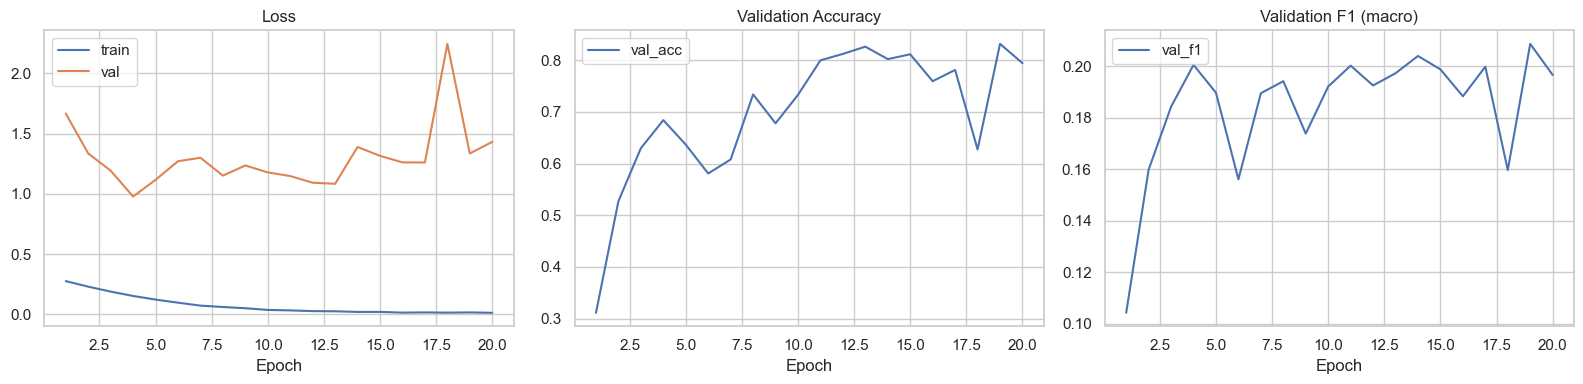

In [14]:
epochs_range = range(1, epochs + 1)
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].plot(epochs_range, history.history.get('loss', []), label='train')
axes[0].plot(epochs_range, history.history.get('val_loss', []), label='val')
axes[0].set_title('Loss')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(epochs_range, history.history.get('val_accuracy', []), label='val_acc')
axes[1].set_title('Validation Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].legend()

axes[2].plot(epochs_range, val_f1_cb.val_f1, label='val_f1')
axes[2].set_title('Validation F1 (macro)')
axes[2].set_xlabel('Epoch')
axes[2].legend()

plt.tight_layout()
plt.show()

## 14) Visualize Evaluation Metrics
Plot confusion matrices and class-wise F1 scores.

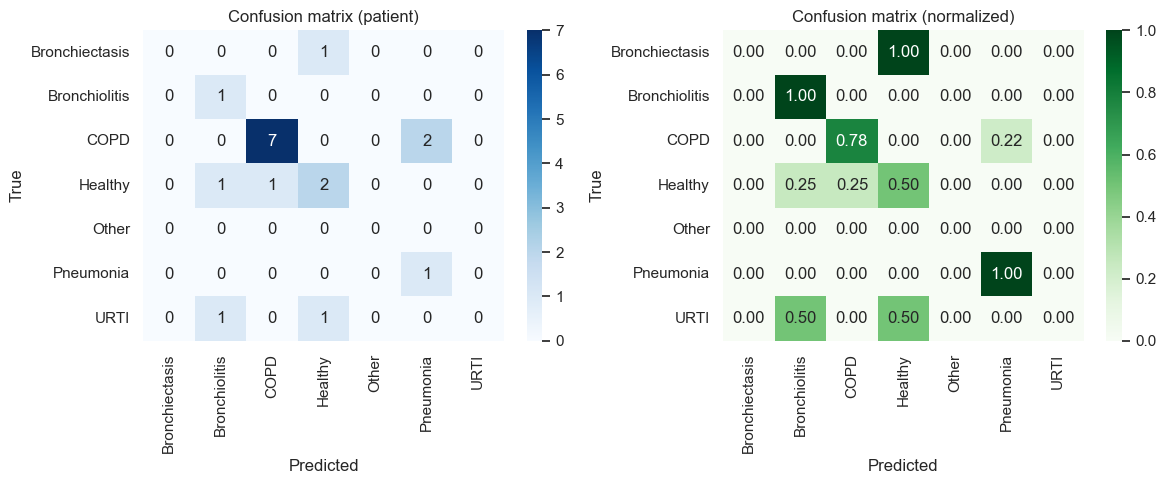

/Users/guilhermekaidei/Desktop/Insper/AI_Medicine/Project/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


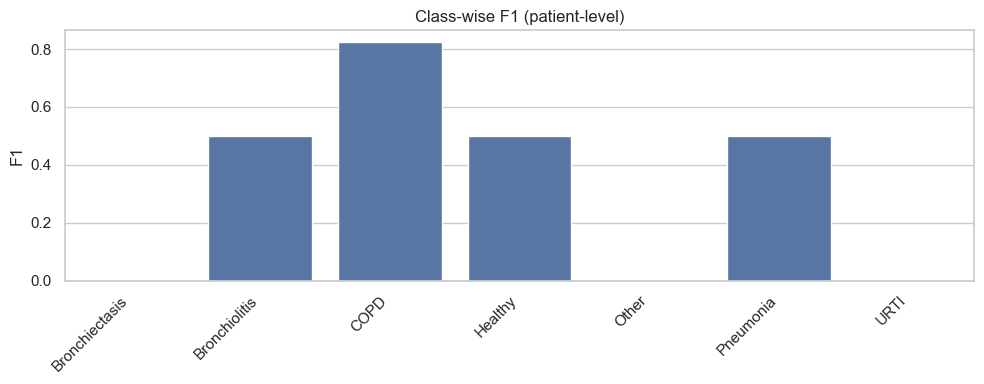

In [15]:
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True).clip(min=1)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_, ax=axes[0])
axes[0].set_title('Confusion matrix (patient)')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('True')
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Greens', xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_, ax=axes[1])
axes[1].set_title('Confusion matrix (normalized)')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('True')
plt.tight_layout()
plt.show()

class_f1 = f1_score(y_true, y_pred, average=None, labels=label_encoder.classes_)
plt.figure(figsize=(10, 4))
sns.barplot(x=label_encoder.classes_, y=class_f1)
plt.title('Class-wise F1 (patient-level)')
plt.ylabel('F1')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 15) Error Analysis: Misclassified Patients
List misclassified patients and optionally visualize their spectrograms.

Misclassified patients: 7


,patient_id,true_label,pred_label,max_confidence
0,102,Healthy,COPD,0.581125
1,105,URTI,Healthy,0.715966
3,116,Bronchiectasis,Healthy,0.507525
6,134,COPD,Pneumonia,0.662133
7,136,Healthy,Bronchiolitis,0.801607
12,188,URTI,Bronchiolitis,0.635878
15,192,COPD,Pneumonia,0.600355


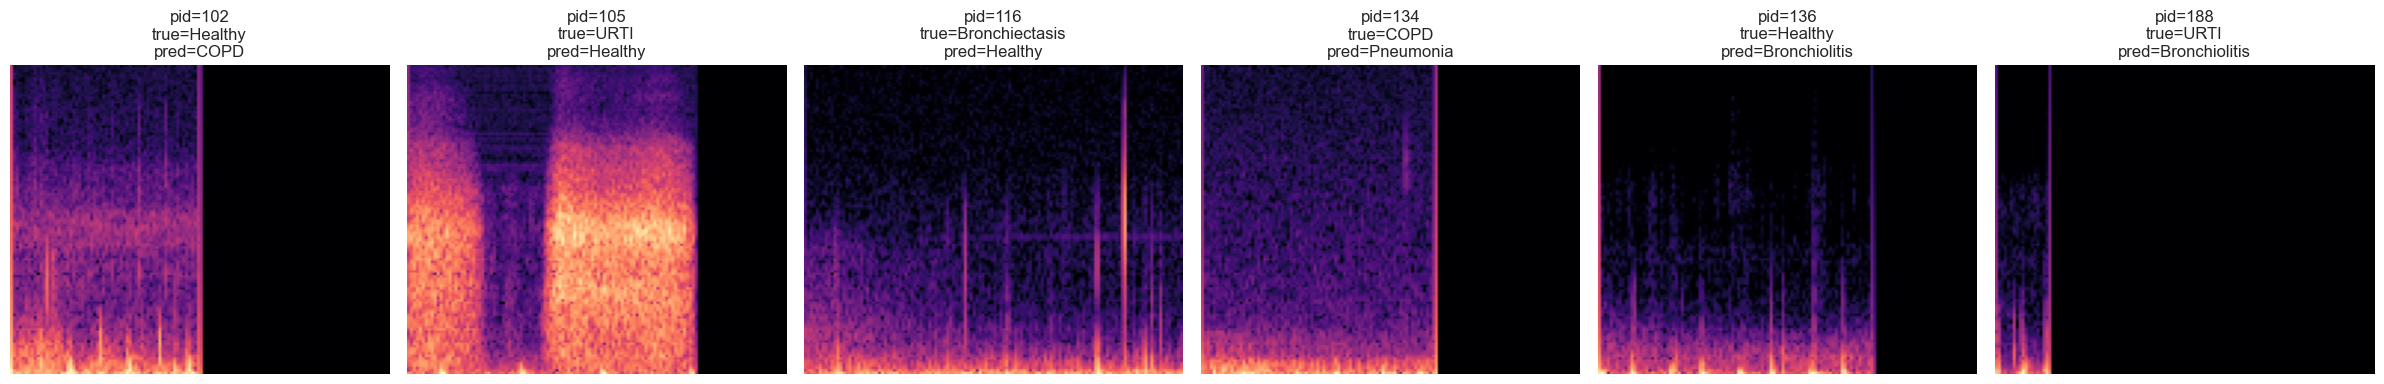

In [16]:
mis_patients = patient_results[patient_results['true_label'] != patient_results['pred_label']].copy()
print('Misclassified patients:', len(mis_patients))
display(mis_patients.head(20))

show_error_specs = True
if show_error_specs and len(mis_patients) > 0:
    sample_pids = mis_patients.sample(min(6, len(mis_patients)), random_state=SEED)['patient_id'].tolist()
    rows = df_splits['test'][df_splits['test']['patient_id'].isin(sample_pids)].copy()
    rows = rows.groupby('patient_id').head(1).reset_index(drop=True)
    fig, axes = plt.subplots(1, len(rows), figsize=(4 * len(rows), 4))
    if len(rows) == 1:
        axes = [axes]
    for ax, (_, row) in zip(axes, rows.iterrows()):
        arr = np.load(row['spec_path_abs'], allow_pickle=False)
        ax.imshow(arr, origin='lower', aspect='auto', cmap='magma')
        pred = mis_patients.loc[mis_patients['patient_id'] == row['patient_id'], 'pred_label'].iloc[0]
        ax.set_title(f"pid={row['patient_id']}\ntrue={row['diagnosis']}\npred={pred}")
        ax.set_axis_off()
    plt.tight_layout()
    plt.show()